---
title: From Tidy to Wide Without Aggregating
subtitle: DS 2023 | Communicating with Data
---

## Overview

In a previous notebook, **Two Ways from Tidy to Wide**, we assumed the following:

- You have a tidy DataFrame $D$ with two grouping variables $g_1$ and $g_2$ and one measurement variable $m$.

- You want a wide table $W$ with $g_1$ on axis 0, $g_2$ on axis 1, and $m$ in the cells.

We covered two possibilities, based on whether $g_1$ and $g_2$ combine to produce a **unique** set over the observations.

- If yes, reshape.
- If no, aggregate and reshape.

This notebook takes up the case where **aggregating is not acceptable**.

That case arises constantly once we start plotting **distributions** in statistical plots. 

For example a histogram, a density plot, and a box plot each require every observation. 

Replacing a group with its mean destroys the very thing we are trying to draw.

So, we have a new scenario to consider:

- You have a tidy DataFrame $D$ with one or more grouping variables, which we refer to collectively as $g$, and one measurement variable $m$.

- The values of $g$ do **not** form a unique key over $D$. Some combination of them occurs more than once.

- Aggregating is not acceptable, because you need every observation.

- You want a wide table $W$ with the levels of $g$ on axis 1 and every value of $m$ running down the columns.

Note what does *not* matter here: how many grouping variables you have. 

What matters is that they fail to identify a row. 

A single variable may fail, as `species` does in `iris` below, and so may a combination, as `species` and `sex` do in `penguins`.

The solution is to manufacture one more grouping variable, chosen so that it completes the key. We will call it $w$, a **within-group ID**.

Once $w$ exists, $w \times g$ is unique, and the two methods from the previous notebook apply unchanged: $w$ goes on axis 0 and $g$ on axis 1.

### Two preconditions

Before manufacturing anything, check two things about $g$. 

Both are quick, and both are checked the same way in every example below.

1. **$g$ is not a key.** If it were, you would reshape directly and this notebook would not apply.

2. **$g$ is complete.** Every row must have a value for $g$.

This second one is easy to overlook and it is not optional: `.groupby()` ignores rows whose grouping value is missing, so those rows receive no within-group ID, and a $w$ with gaps in it is not a key. 

So, we need to decide what to do about them *before* reshaping, not after the reshape fails.

## Flowchart

This flowchart extends the one from the previous notebook.

```mermaid
flowchart TD

    A["Check that g is complete<br>D[g].isna().sum() == 0"]

    A -->|"incomplete"| B["Decide and act now:<br>drop the rows, or give them<br>an explicit group label"]

    A --> C["Check if g1 x g2 combinations are unique over D by using D.value_counts(['g1','g2'])"]

    B --> C

    C --> D{"Does every count == 1?"}

    D -->|"Yes: each pair occurs<br>at most once"| E["Pure reshape<br>(see Two Ways from Tidy to Wide)"]

    D -->|"No: some pairs repeat"| F{"Aggregate or transform?"}

    F -->|"Aggregate:<br>collapse each group<br>to one value"| G["Aggregate and reshape<br>(see Two Ways from Tidy to Wide)"]

    F -->|"Transform:<br>keep every row"| H["Manufacture w with a transformation,<br>so that w x g becomes unique<br>D['w'] = D.groupby(g).cumcount()"]

    H --> H1["D.pivot(index='w',<br>columns='g',<br>values='m')"]

    H --> H2["D.set_index(['w','g'])['m']<br>.unstack('g')"]

    H1 --> Z["W: rows = position within group, cols = G levels, cells = M"]

    H2 --> Z

    classDef unique fill:#d8f0d8,stroke:#4a8a4a,color:#1c3a1c
    classDef dup fill:#fde4d4,stroke:#c07a45,color:#4a2a12
    classDef new fill:#d9e6f7,stroke:#41689e,color:#16283f
    classDef pre fill:#efe6f7,stroke:#7a5aa0,color:#2b1c3d
    class A,B pre
    class E unique
    class G dup
    class H,H1,H2 new
```

## Example 1

We use `iris`, which records four measurements for $150$ flowers of three species.

### Get the data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Choose the variables

Here $g$ is a single variable. We assign it and $m$.

In [4]:
a_g = 'species'
a_m = 'petal_length'

### Check the preconditions

Let's check completeness first.

Are there any null values? 

Here's a quick way to find out.

In [5]:
iris[a_g].isna().sum()

np.int64(0)

We see that there a no missing values, so every row will receive a number.

Now let's test for uniqueness. 

This is the same check as in the previous notebook, applied to whatever $g$ happens to be. 

Here's a one-liner you can use.

The `value_counts` method returns results in descending order, so any values greater than $1$ would appear first.

In [4]:
iris.value_counts([a_g]).head(1)

species
setosa     50
Name: count, dtype: int64

We can see that the domain is not unique: each species occurs $50$ times. 

So $g$ is not a key.

By the previous notebook we would now aggregate. 

But we want a box plot, so we need all $150$ measurements. 

### See what goes wrong without an index

It is worth seeing what Pandas does if we ask for the reshape and give it no index.

In [9]:
staircase = iris.pivot(columns=a_g, values=a_m)
staircase.sample(10).sort_index()

species,setosa,versicolor,virginica
8,1.4,NaN,NaN
14,1.2,NaN,NaN
50,NaN,4.7,NaN
56,NaN,4.7,NaN
62,NaN,4.0,NaN
67,NaN,4.1,NaN
74,NaN,4.3,NaN
86,NaN,4.7,NaN
117,NaN,NaN,6.7
144,NaN,NaN,5.7


No error was raised, but the table not well organized. 

This result occurred because Pandas used the dataframe's raw row numbers for the index. 

Every row number belongs to exactly one species, so each row holds one value and two blanks. 

The result is $150$ values scattered across $450$ cells in a staircase pattern.

What we need is a row label meaning **the nth flower of its species**, so that the first setosa, the first versicolor, and the first virginica all land on row $0$.

### Manufacture $w$

To accomplish this goal, we can use `.cumcount()`, which numbers the rows within each group, starting at $0$ and starting over at each new group.

In [12]:
a_w = 'within_group_id'

iris[a_w] = iris.groupby(a_g).cumcount()

The behavior to notice is what happens at a group boundary. `iris` is ordered by species, so the change occurs at row $50$.

In [13]:
iris.loc[48:52, [a_g, a_m, a_w]]

,species,petal_length,within_group_id
48,setosa,1.5,48
49,setosa,1.4,49
50,versicolor,4.7,0
51,versicolor,4.5,1
52,versicolor,4.9,2


The counter reaches $49$ at the last setosa and resets to $0$ at the first versicolor.

Each species is therefore numbered $0$ through $49$, and $w \times g$ is now unique. We can verify this with the same check we used above.

In [16]:
iris.value_counts([a_w, a_g]).head(1)

within_group_id  species
0                setosa     1
Name: count, dtype: int64

> [!NOTE]
>
> The method `.cumcount()` is what Pandas calls a "transformation".
>
> Transformations are applied to groups generated by `groupby` but they don't change the number of rows returned.
>
> Pandas has a `transform` method that can be used in conjunction with `groupby`.
>
> Using this method, we could have written:
>
> ```python
> D.groupby(g).transform('cumcount')
> ```
> This returns exactly the same values.

### Reshape

Having manufactured $w$, both methods from the previous notebook apply unchanged, with $w$ in the $g_1$ position and $g$ in the $g_2$ position.

#### Method 1: Pivoting

In [17]:
iris.pivot(index=a_w, columns=a_g, values=a_m).head()

species,setosa,versicolor,virginica
within_group_id,,,
0,1.4,4.7,6.0
1,1.4,4.5,5.1
2,1.3,4.9,5.9
3,1.5,4.0,5.6
4,1.4,4.6,5.8


#### Method 2: Unstacking

In [18]:
iris.set_index([a_w, a_g])[a_m].unstack().head()

species,setosa,versicolor,virginica
within_group_id,,,
0,1.4,4.7,6.0
1,1.4,4.5,5.1
2,1.3,4.9,5.9
3,1.5,4.0,5.6
4,1.4,4.6,5.8


The staircase has collapsed from $150$ rows into $50$, with every cell filled.

$W$ is now in the shape our plotting functions expect.

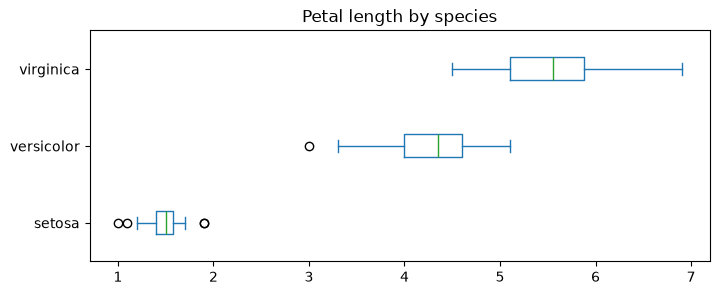

In [19]:
iris.pivot(index=a_w, columns=a_g, values=a_m).plot.box(vert=False, figsize=(8, 3))
plt.title('Petal length by species')
plt.show()

## Example 2: Groups of different sizes

The `iris` dataset is unusually tidy: it has exactly $50$ flowers per species, no missing values, and is already ordered by group.

Real data is rarely so well organized and complete. 

The next three examples cover cases where data need to be adjusted before transforming

We will use the  `penguins` dataset.

### Get the data

In [21]:
penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Let's take a quick look at the distribution of `species` values.

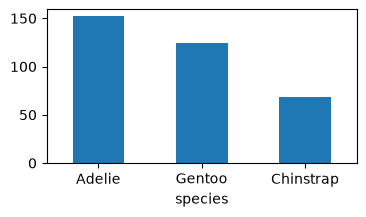

In [25]:
penguins.species.value_counts().plot.bar(rot=0, figsize=(4,2))
plt.show()

### Choose the variables

Let's map the columns to their roles in the pattern we are demonstrating.

Note, we have not yet created `within_group_id`.

In [29]:
b_w = 'within_group_id'
b_g = 'species'
b_m = 'body_mass_g'

### Check the preconditions

Before making any changes, let's check if there are any null values.

In [30]:
penguins[b_g].isna().sum()

np.int64(0)

Looks there are none.

Now let's check for uniqueness.

In [31]:
penguins.value_counts([b_g]).head(1)

species
Adelie     152
Name: count, dtype: int64

We see that they are not unique.

Both preconditions are as in our first example, so we may proceed exactly as before.

We create our within group ID and then widen the table with it.

In [34]:
penguins[b_w] = penguins.groupby(b_g).cumcount()
mass_by_species = penguins.pivot(index=b_w, columns=b_g, values=b_m)
mass_by_species.head()

species,Adelie,Chinstrap,Gentoo
within_group_id,,,
0,3750.0,3500.0,4500.0
1,3800.0,3900.0,5700.0
2,3250.0,3650.0,4450.0
3,NaN,3525.0,5700.0
4,3450.0,3725.0,5400.0


### Ragged tables

Let's take a quick look at the tail end of the dataframe:

In [36]:
mass_by_species.tail()

species,Adelie,Chinstrap,Gentoo
within_group_id,,,
147,3475.0,NaN,NaN
148,3450.0,NaN,NaN
149,3750.0,NaN,NaN
150,3700.0,NaN,NaN
151,4000.0,NaN,NaN


Notice this null values in the second two species.

This is because the dataframe $W$ has as many rows as the largest group, $152$, and the shorter columns are padded with `NaN` at the bottom.

This is called a "ragged" table. 

In this contenxt this is expected and actually harmless. 

Pandas' plotting functions ignore missing values, so each plot is drawn only from the observations that exist.

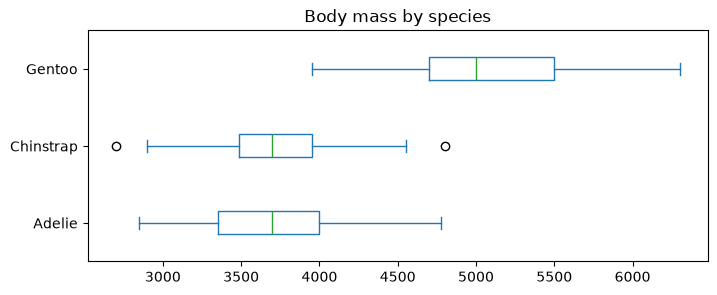

In [39]:
mass_by_species.plot.box(vert=False, figsize=(8, 3))
plt.title('Body mass by species')
plt.show()

## Example 3: An incomplete grouping variable

Now let's look at a case where grouping variable is **not complete**. 

### Choose the variables

In [40]:
c_w = 'within_group_id'
c_g = 'sex'
c_m = 'body_mass_g'

### Check the preconditions

In [44]:
penguins[c_g].isna().sum()

np.int64(11)

In [43]:
penguins.value_counts([c_g]).head(1)

sex 
Male    168
Name: count, dtype: int64

The group is not unique, as expected. 

But $11$ rows have no value for `sex`, so the completeness precondition fails.

It is worth seeing exactly what that costs, because the error you eventually get does not describe the problem.

In [46]:
penguins[c_w] = penguins.groupby(c_g).cumcount()
penguins.loc[penguins[c_g].isna(), ['species', c_g, c_w]].head()

,species,sex,within_group_id
3,Adelie,NaN,NaN
8,Adelie,NaN,NaN
9,Adelie,NaN,NaN
10,Adelie,NaN,NaN
11,Adelie,NaN,NaN


`.groupby()` ignored those rows, so `.cumcount()` had no number to give them and every one received `NaN`.

Eleven rows now share the same index value, and the reshape fails.

In [47]:
try:
    penguins.pivot(index=c_w, columns=c_g, values=c_m)
except ValueError as e:
    print('ValueError:', e)

ValueError: Index contains duplicate entries, cannot reshape


The message names duplicate entries in the index, which is accurate and unhelpful. 

The duplicates are the missing values.

### Handling missing values

You have two options at this point.

- **Drop the rows.** Correct when a penguin of unrecorded sex belongs in neither column.
- **Give them an explicit label.** Correct when "unknown" is itself a group worth seeing.

The choice depends on a few factors, such as what a null actually means in terms of data collection, whether it is worth imputing missing values, etc.

Here we wiil drop them. 

> [!NOTE]
>
> Note the order of operation here: assign $w$ first, then drop, then reshape.
>
> Dropping first would also work, but it changes the dataframe you are working with, and $D$ should stay intact.

So now we know to drop rows where `c_g`, i.e. `sex`, is null before pivoting.

In [51]:
mass_by_sex = penguins.dropna(subset=[c_g]).pivot(
    index=c_w, columns=c_g, values=c_m)
mass_by_sex

sex,Female,Male
within_group_id,,
0.0,3800.0,3750.0
1.0,3250.0,3650.0
2.0,3450.0,4675.0
3.0,3625.0,3800.0
4.0,3200.0,4400.0
...,...,...
163.0,4850.0,5500.0
164.0,5200.0,5850.0
165.0,NaN,6000.0


In [52]:
mass_by_sex.count()

sex
Female    165
Male      168
dtype: int64

## Example 4: Several grouping variables

Nothing in the method requires $g$ to be a single column. 

You can pass a list of columns to `.groupby()` and the result will contain a hierarchical column index.

We check the preconditions in the same way. 

We already know from Example 3 that `sex` is incomplete, so that is handled first and nothing about it is new here.

### Choose the variables

In [53]:
d_w = 'within_group_id'
d_g = ['species', 'sex']
d_m = 'body_mass_g'

### Check the preconditions

In [57]:
penguins[d_g].isna().sum()

species     0
sex        11
dtype: int64

In [58]:
penguins.value_counts(d_g).head(1)

species  sex 
Adelie   Male    73
Name: count, dtype: int64

`species` is complete and `sex` is not, so the same eleven rows are removed. 

Then the reshape proceeds as in every other example.

In [60]:
penguins[d_w] = penguins.groupby(d_g).cumcount()
mass_by_group = penguins.dropna(subset=d_g).pivot(
    index=d_w, columns=d_g, values=d_m)
mass_by_group

species          Adelie         Chinstrap          Gentoo        
sex                Male  Female    Female    Male  Female    Male
within_group_id                                                  
0.0              3750.0  3800.0    3500.0  3900.0  4500.0  5700.0
1.0              3650.0  3250.0    3525.0  3650.0  4450.0  5700.0
2.0              4675.0  3450.0    3950.0  3725.0  4550.0  5400.0
3.0              3800.0  3625.0    3250.0  3750.0  4800.0  5200.0
4.0              4400.0  3200.0    4150.0  3700.0  4400.0  5150.0
...                 ...     ...       ...     ...     ...     ...
68.0             3725.0  3050.0       NaN     NaN     NaN     NaN
69.0             3650.0  3000.0       NaN     NaN     NaN     NaN
70.0             4250.0  3475.0       NaN     NaN     NaN     NaN
71.0             3750.0  3450.0       NaN     NaN     NaN     NaN
72.0             4000.0  3700.0       NaN     NaN     NaN     NaN

[73 rows x 6 columns]

In [61]:
mass_by_group.count()

species    sex   
Adelie     Male      73
           Female    73
Chinstrap  Female    34
           Male      34
Gentoo     Female    58
           Male      61
dtype: int64

The column index now has one level per grouping variable.

If you would rather have flat labels, combine the grouping variables into a single column before grouping.

Concatening the two values does this, and it yields `NaN` wherever either part is missing — which means the completeness check then covers the combination in one step.

In [73]:
penguins['group'] = penguins.species + " " + penguins.sex
# penguins['group'] = penguins.species.str.cat(penguins.sex, sep=' ') # Another way 

Check for missing values:

In [71]:
penguins['group'].isna().sum()

np.int64(11)

In [69]:
penguins[d_w] = penguins.groupby('group').cumcount()
penguins.dropna(subset=['group']).pivot(
    index=d_w, columns='group', values=d_m).count()

group
Adelie Female       73
Adelie Male         73
Chinstrap Female    34
Chinstrap Male      34
Gentoo Female       58
Gentoo Male         61
dtype: int64

## Understang what $W$ means

The manufactured $w$ is a position, not a measurement. 

It carries no information about the observation.

This limits how $W$ may be used.

> [!WARNING]
>
> The rows of $W$ are not aligned in any meaningful way.
>
> The setosa on row $7$ has nothing to do with the virginica on row $7$.
>
> Each is simply the eighth flower of its species in the order the file happened to list them.
>
> It would be a mistake to subtract one column from another, to correlate them, or to treat a row as an observation.

A $W$ built on a manufactured index is a convenience for plotting, not a tidy dataset. 

Build it, plot it, and return to $D$ for anything else.

## Controlling the order

The `cumcount` method numbers rows in the order they appear in $D$. It does not sort anything.

So if the numbering should mean something, sort $D$ first.

Sorting by the measurement, for instance, makes each column of $W$ ascend.

In [74]:
iris_sorted = iris.sort_values([a_g, a_m])
iris_sorted[a_w] = iris_sorted.groupby(a_g).cumcount()
iris_sorted.pivot(index=a_w, columns=a_g, values=a_m).head()

species,setosa,versicolor,virginica
within_group_id,,,
0,1.0,3.0,4.5
1,1.1,3.3,4.8
2,1.2,3.3,4.8
3,1.2,3.5,4.9
4,1.3,3.5,4.9


For a box plot or a histogram this makes no difference, since those plots do not care in what order the values arrive.

It matters when you want $W$ to be readable, or when you intend to take the first $n$ rows of each group.

### Numbering by a column without sorting

Sorting changes $D$. So, if the numbering should follow a column but you would rather leave the sort order of the dataframe as it arrived, use a different transformation.

The method `rank` assigns each row its position within its group under some ordering. 

For example, it assigns $1$ to the row with the highest or lowest value of a measure in the group.

When two rows have the same value, a tie can be broken in various ways.

With `method='first'`, ties are broken by positon, so every row receives a distinct rank and $w \\times g$ stays unique.

In [79]:
iris[a_w] = iris.groupby(a_g)[a_m].rank(method='first').astype(int)
iris.pivot(index=a_w, columns=a_g, values=a_m).head()

species,setosa,versicolor,virginica
within_group_id,,,
1,1.0,3.0,4.5
2,1.1,3.3,4.8
3,1.2,3.3,4.8
4,1.2,3.5,4.9
5,1.3,3.5,4.9


This is the same $W$ the sort produced, and $D$ is untouched.

The only difference is that `rank` starts with $1$.

## General Function

To conclude, we define a general function that takes a tidy dataframe as its first argument and returns a wide dataframe based on some parameters.

This one takes $g$ and $m$ only, since $w$ is manufactured rather than supplied.

In [85]:
def tidy2wide_all(tidy, g, m, w='within_group_id', method='pivot', sort_by=None):

    D = tidy.copy()

    # Sort first if the numbering should mean something
    if sort_by is not None:
        D = D.sort_values(sort_by)

    # Manufacture the index
    D[w] = D.groupby(g).cumcount()

    # Rows with a missing grouping value got no number, so remove them
    keys = [g] if isinstance(g, str) else list(g) # This makes sure g is a list
    D = D.dropna(subset=keys)

    if method == 'pivot':
        wide = D.pivot(index=w, columns=g, values=m)
    elif method == 'unstack':
        wide = D.set_index([w] + keys)[m].unstack(keys)
    else:
        raise ValueError("Invalid method.")

    return wide

In [86]:
tidy2wide_all(iris, 'species', 'petal_length').head()

species,setosa,versicolor,virginica
within_group_id,,,
0,1.4,4.7,6.0
1,1.4,4.5,5.1
2,1.3,4.9,5.9
3,1.5,4.0,5.6
4,1.4,4.6,5.8


In [94]:
tidy2wide_all(penguins, 'species', 'body_mass_g', method='unstack').head()

species,Adelie,Chinstrap,Gentoo
within_group_id,,,
0,3750.0,3500.0,4500.0
1,3800.0,3900.0,5700.0
2,3250.0,3650.0,4450.0
3,NaN,3525.0,5700.0
4,3450.0,3725.0,5400.0


In [93]:
tidy2wide_all(penguins, ['species', 'sex'], 'body_mass_g').head()

species          Adelie         Chinstrap          Gentoo        
sex                Male  Female    Female    Male  Female    Male
within_group_id                                                  
0.0              3750.0  3800.0    3500.0  3900.0  4500.0  5700.0
1.0              3650.0  3250.0    3525.0  3650.0  4450.0  5700.0
2.0              4675.0  3450.0    3950.0  3725.0  4550.0  5400.0
3.0              3800.0  3625.0    3250.0  3750.0  4800.0  5200.0
4.0              4400.0  3200.0    4150.0  3700.0  4400.0  5150.0

In [92]:
tidy2wide_all(iris, 'species', 'petal_length', sort_by=['species', 'petal_length']).head()

species,setosa,versicolor,virginica
within_group_id,,,
0,1.0,3.0,4.5
1,1.1,3.3,4.8
2,1.2,3.3,4.8
3,1.2,3.5,4.9
4,1.3,3.5,4.9


## Summary

:::{table}
| Condition | Method |
| --- | --- |
| $g_1 \times g_2$ is unique | `.pivot()` or `.set_index().unstack()` |
| Not unique, one summary value per cell is acceptable | `.pivot_table()` or `.groupby().unstack()` |
| Not unique, every observation must be kept | Manufacture $w$ with `.cumcount()`, then either method above |
:::

Three things to remember about the third row.

Check that $g$ is complete before anything else. Rows with no group get no number, and a $w$ with gaps is not a key.

$w$ comes from a **transformation**, not an aggregation. That is what distinguishes this case from the previous notebook's second one.

`.cumcount()` numbers rows in the order they appear. To number by a column instead, sort $D$ first or use `.rank(method='first')`, which leaves $D$ alone.

Groups of different sizes produce a ragged $W$ padded with `NaN`. This is normal, and plotting functions handle it.

$W$ is not tidy. Its rows are not observations, and reading across a row is meaningless.